# Monte Carlo pricing and delta hedging — analysis

Each `*_hedge.json` in `../results/` is the day-by-day journal of a hedging portfolio that replicates
a path-dependent option on several correlated shares. At every rebalancing date the pricer re-runs
the Monte Carlo from the observed past, and two columns come out:

- **`price`** — the option's Monte Carlo price, conditional on the path seen so far
- **`value`** — the self-financing portfolio's value (shares held at the current deltas, plus cash)

They are equal by construction on day 0. How close they stay afterwards is the test of the whole
chain: model, payoff, finite-difference deltas and the cash recursion all have to be right for the
gap to be noise rather than drift.

In [1]:
import json, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path("../results")
SCENARIOS = Path("../scenarios")
PLOTS = Path("../docs/plots")
PLOTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
BLUE, RED, GREY, GREEN = "#1f77b4", "#d62728", "#7f7f7f", "#2ca02c"

def params(name):
    return json.load(open(SCENARIOS / name / "params.json"))

def market(name):
    return np.loadtxt(SCENARIOS / name / "market.txt", ndmin=2)

def hedge(name):
    return json.load(open(RESULTS / f"{name}_hedge.json"))

def journal(name):
    h = hedge(name)
    df = pd.DataFrame(h["portfolio"])
    T = params(name)["option"]["maturity"]
    df["t"] = df["date"] * T / (len(df) - 1)
    return df.set_index("t")

def deltas(name):
    df = journal(name)
    return pd.DataFrame(df["deltas"].tolist(), index=df.index)

names = ["call_1d", "basket_3d", "asian_2d", "perf_4d", "basket_10d"]
timings = pd.read_csv(RESULTS / "timings.csv").set_index("scenario")

## Summary across the five scenarios

`tracking error` is the final gap `value − payoff`, relative to the initial option price. The hedge
time is the whole replication (H + 1 prices and H + 1 delta vectors, 50 000 paths each).

In [2]:
rows = []
for name in names:
    p, h, df = params(name), hedge(name), journal(name)
    rows.append({
        "scenario": name,
        "type": p["option"]["type"],
        "D": p["model"]["size"],
        "N": p["option"]["fixingDates"],
        "H": p["hedging"]["rebalancingDates"],
        "price_0": df.price.iloc[0],
        "± std": df.priceStdDev.iloc[0],
        "payoff": h["finalPayoff"],
        "value_H": df.value.iloc[-1],
        "P&L": h["finalPnL"],
        "tracking error": h["finalPnL"] / df.price.iloc[0],
        "hedge time (s)": timings.loc[name, "hedge_seconds"],
    })
summary = pd.DataFrame(rows).set_index("scenario")
summary.style.format({"price_0": "{:.3f}", "± std": "{:.3f}", "payoff": "{:.3f}", "value_H": "{:.3f}",
                      "P&L": "{:+.3f}", "tracking error": "{:+.1%}", "hedge time (s)": "{:.1f}"})

,type,D,N,H,price_0,± std,payoff,value_H,P&L,tracking error,hedge time (s)
scenario,,,,,,,,,,,
call_1d,basket,1,1,252,13.860,0.086,13.701,14.200,+0.499,+3.6%,1.5
basket_3d,basket,3,1,252,8.296,0.054,16.895,16.483,-0.413,-5.0%,3.5
asian_2d,asian,2,12,252,4.371,0.029,0.000,0.260,+0.260,+5.9%,11.1
perf_4d,performance,4,12,120,1.245,0.001,1.155,1.147,-0.007,-0.6%,11.9
basket_10d,basket,10,1,250,7.795,0.050,5.590,5.369,-0.221,-2.8%,12.6


## One share, rebalanced daily — with a closed form to check against

`call_1d` is a vanilla call: one share at 100, strike 95, volatility 25 %, one year, hedged on 252
dates. Because it is the one payoff with a closed form, the Black-Scholes price and delta can be laid
over the Monte Carlo ones at every rebalancing date.

In [3]:
def N(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def bs_call(S, K, tau, r, sigma):
    if tau <= 0:
        return max(S - K, 0.0), float(S > K)
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * math.sqrt(tau))
    d2 = d1 - sigma * math.sqrt(tau)
    return S * N(d1) - K * math.exp(-r * tau) * N(d2), N(d1)

p = params("call_1d")
K, T, r, sigma = p["option"]["strike"], p["option"]["maturity"], p["model"]["rate"], p["model"]["volatility"][0]
S = market("call_1d")[:, 0]
df = journal("call_1d")
closed = [bs_call(s, K, T - t, r, sigma) for s, t in zip(S, df.index)]
df["bs_price"] = [c[0] for c in closed]
df["bs_delta"] = [c[1] for c in closed]
df["mc_delta"] = deltas("call_1d")[0]

z = (df.price - df.bs_price) / df.priceStdDev
print(f"Monte Carlo vs Black-Scholes over {len(df)} dates:")
print(f"  |price - closed form|  mean {abs(df.price - df.bs_price).mean():.4f}   max {abs(df.price - df.bs_price).max():.4f}")
print(f"  z-score               mean {z.mean():+.2f}   std {z.std():.2f}   |z| > 3 on {(abs(z) > 3).sum()} dates")
print(f"  |delta - N(d1)|        mean {abs(df.mc_delta - df.bs_delta).mean():.4f}   max {abs(df.mc_delta - df.bs_delta).max():.4f}")

Monte Carlo vs Black-Scholes over 253 dates:
  |price - closed form|  mean 0.0518   max 0.2169
  z-score               mean -0.06   std 0.98   |z| > 3 on 0 dates
  |delta - N(d1)|        mean 0.0016   max 0.0079


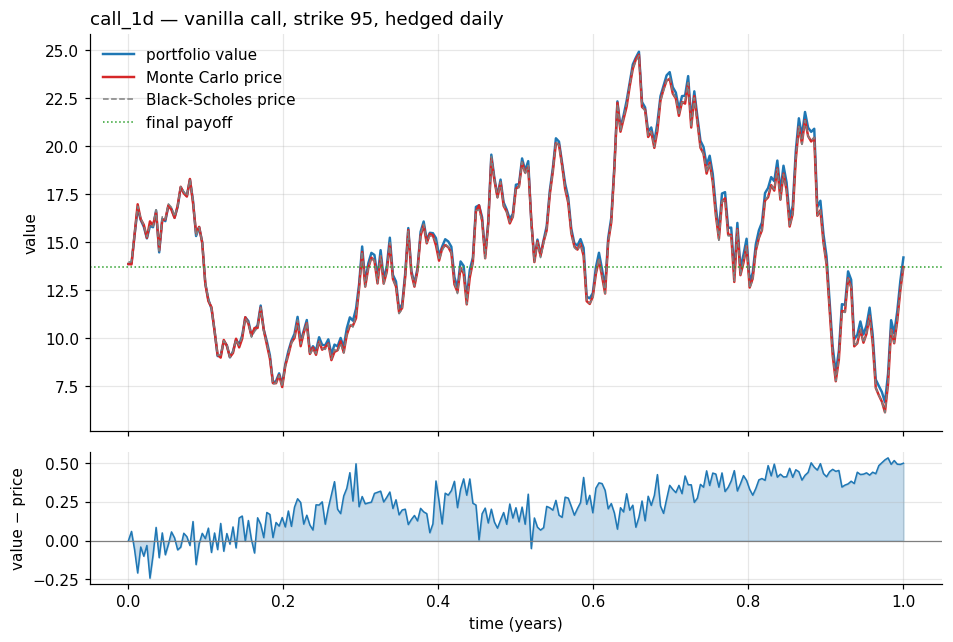

gap: max +0.533   min -0.242   final +0.499   final P&L +0.499


In [4]:
def plot_tracking(name, title, filename, extra=None):
    df = journal(name)
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True,
                                  gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})
    ax.plot(df.index, df.value, color=BLUE, lw=1.6, label="portfolio value")
    ax.plot(df.index, df.price, color=RED, lw=1.6, label="Monte Carlo price")
    if extra is not None:
        ax.plot(df.index, extra, color=GREY, lw=1.0, ls="--", label="Black-Scholes price")
    ax.axhline(hedge(name)["finalPayoff"], color=GREEN, lw=1.0, ls=":", label="final payoff")
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_ylabel("value")
    ax.legend(loc="upper left")
    gap = df.value - df.price
    ax2.fill_between(df.index, gap, 0, color=BLUE, alpha=0.25)
    ax2.plot(df.index, gap, color=BLUE, lw=1.0)
    ax2.axhline(0, color=GREY, lw=0.8)
    ax2.set_ylabel("value − price")
    ax2.set_xlabel("time (years)")
    fig.savefig(PLOTS / filename, bbox_inches="tight")
    plt.show()
    return gap

gap = plot_tracking("call_1d", "call_1d — vanilla call, strike 95, hedged daily", "call_1d.png", extra=df.bs_price)
print(f"gap: max {gap.max():+.3f}   min {gap.min():+.3f}   final {gap.iloc[-1]:+.3f}   final P&L {hedge('call_1d')['finalPnL']:+.3f}")

The Monte Carlo price sits on the Black-Scholes curve at all 253 dates: the mean absolute gap is
0.05 on prices that range from 6 to 25, the z-scores have mean −0.06 and standard deviation 0.98,
and none exceeds 3. The share goes from 100 to 108.7 through a low of 91 and a high of 118, the
option is multiplied by 4 and divided by 4 along the way, and the portfolio follows every turn
without anticipating any of them.

The gap `value − price` is not pure noise here: it wanders between −0.24 and +0.53 and finishes at
+0.50, 3.6 % of the premium, with a visible upward drift. The next cell explains where it comes from.

In [5]:
# Discrete hedging P&L ≈ Σ ½·Γ·S²·(σ²·dt − (ΔS/S)²), compounded to maturity, with the Black-Scholes gamma.
def bs_gamma(S, tau):
    if tau <= 0:
        return 0.0
    d1 = (math.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * math.sqrt(tau))
    return math.exp(-0.5 * d1 * d1) / math.sqrt(2 * math.pi) / (S * sigma * math.sqrt(tau))

H = len(S) - 1
dt = T / H
estimate = sum(0.5 * bs_gamma(S[i], T - i * dt) * S[i]**2 * (sigma**2 * dt - (S[i + 1] / S[i] - 1)**2) * math.exp(r * (T - (i + 1) * dt))
               for i in range(H))
realized = np.diff(np.log(S)).std(ddof=1) * math.sqrt(H / T)
print(f"realized volatility {realized:.3f} vs model {sigma:.2f}")
print(f"gamma-weighted variance mismatch: {estimate:+.3f}    realized hedging P&L: {hedge('call_1d')['finalPnL']:+.3f}")

realized volatility 0.231 vs model 0.25
gamma-weighted variance mismatch: +0.581    realized hedging P&L: +0.499


A hedger who rebalances once a day is exposed to the difference between the variance the model
charged for and the variance the path delivered, weighted by gamma. The share realized 23.1 %
against the 25 % the model was calibrated to, so a seller hedging at 25 % keeps the difference:
the gamma-weighted estimate is +0.58 and the hedge actually made +0.50. Both the sign and the size
of the drift are accounted for by the volatility mismatch, which is the behaviour a correct delta
hedge should have — the residual (±0.2, visible as the jitter of the gap) is the daily rebalancing
noise.

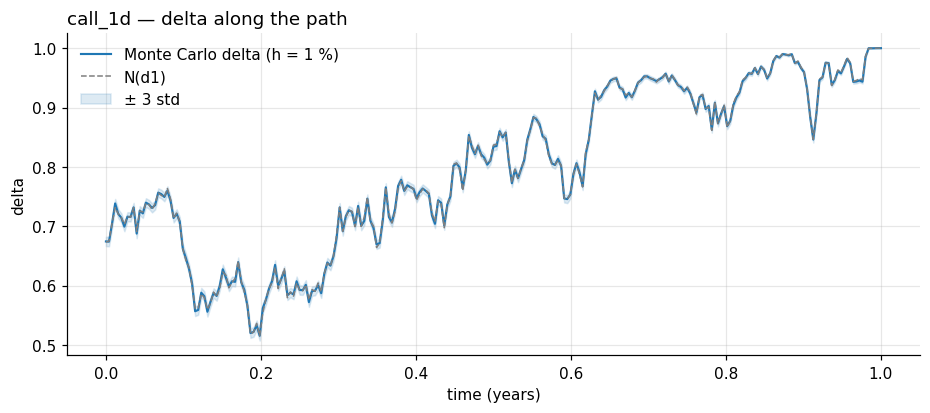

In [6]:
sd = pd.DataFrame(journal("call_1d")["deltasStdDev"].tolist(), index=df.index)[0]
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(df.index, df.mc_delta, color=BLUE, lw=1.4, label="Monte Carlo delta (h = 1 %)")
ax.plot(df.index, df.bs_delta, color=GREY, lw=1.0, ls="--", label="N(d1)")
ax.fill_between(df.index, df.mc_delta - 3 * sd, df.mc_delta + 3 * sd, color=BLUE, alpha=0.15, label="± 3 std")
ax.set_title("call_1d — delta along the path", loc="left", fontsize=12)
ax.set_xlabel("time (years)"); ax.set_ylabel("delta"); ax.legend(loc="upper left")
fig.savefig(PLOTS / "call_1d_delta.png", bbox_inches="tight")
plt.show()

With a 1 % bump the finite-difference delta reproduces N(d1) all along the path: mean absolute error
0.0016, maximum 0.008, and the ±3 standard-deviation band is barely wider than the line. The
step-size section at the end shows what a 10 % bump would have done instead.

## Three correlated shares

`basket_3d`: a call on `0.5·S¹ + 0.3·S² + 0.2·S³`, strike 100, volatilities 20 / 25 / 30 %,
correlation 0.3. No closed form here, so the portfolio is the only check.

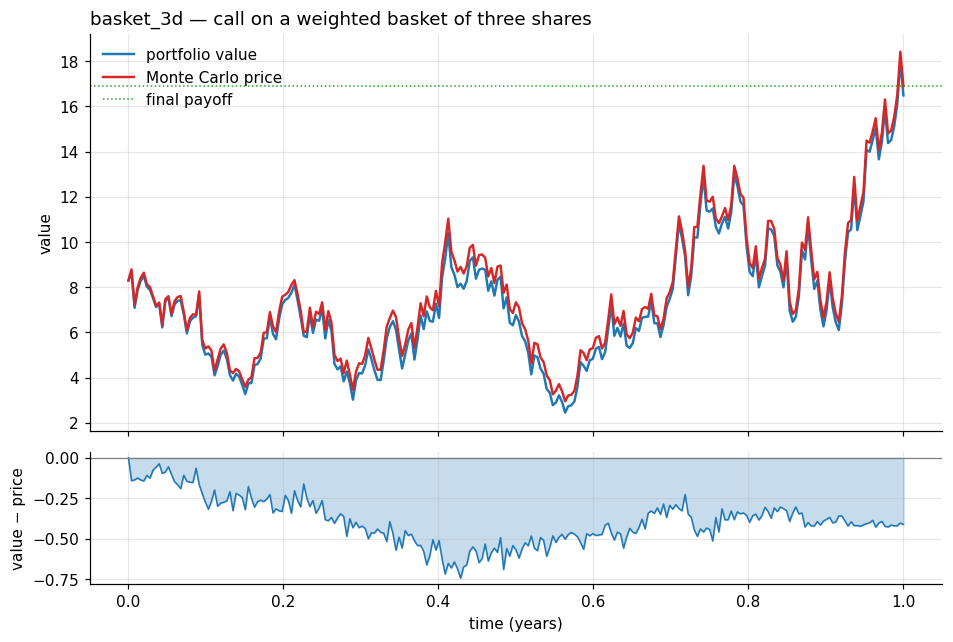

basket at maturity: 116.90   (shares [136.88  97.19  96.5 ])
gap: max +0.000   min -0.745   final P&L -0.413


In [7]:
gap = plot_tracking("basket_3d", "basket_3d — call on a weighted basket of three shares", "basket_3d.png")
S = market("basket_3d"); w = params("basket_3d")["option"]["weights"]
print(f"basket at maturity: {S[-1] @ w:.2f}   (shares {np.round(S[-1], 2)})")
print(f"gap: max {gap.max():+.3f}   min {gap.min():+.3f}   final P&L {hedge('basket_3d')['finalPnL']:+.3f}")

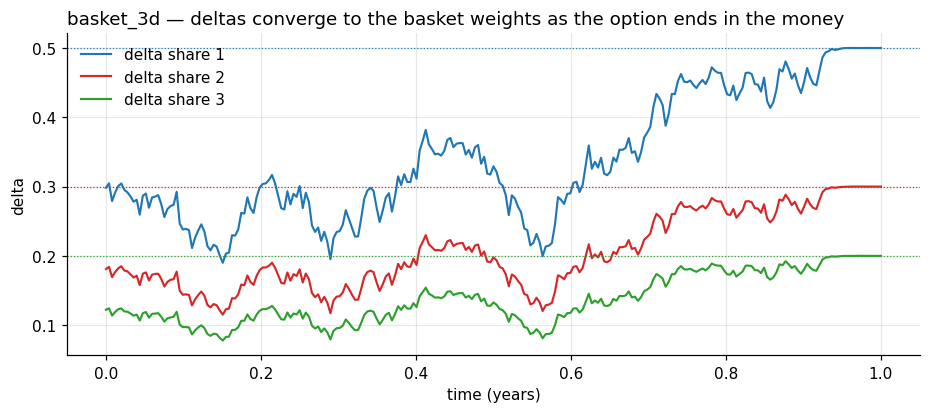

final deltas [0.5 0.3 0.2]   weights [0.5, 0.3, 0.2]


In [8]:
d = deltas("basket_3d")
fig, ax = plt.subplots(figsize=(10, 3.8))
for i, (c, wi) in enumerate(zip([BLUE, RED, GREEN], w)):
    ax.plot(d.index, d[i], color=c, lw=1.4, label=f"delta share {i + 1}")
    ax.axhline(wi, color=c, lw=0.8, ls=":")
ax.set_title("basket_3d — deltas converge to the basket weights as the option ends in the money", loc="left", fontsize=12)
ax.set_xlabel("time (years)"); ax.set_ylabel("delta"); ax.legend(loc="upper left")
fig.savefig(PLOTS / "basket_3d_deltas.png", bbox_inches="tight")
plt.show()
print("final deltas", np.round(d.iloc[-1].values, 3), "  weights", w)

The basket spends 151 of the 253 days within 5 points of the strike — the highest-gamma region — then
share 1 rallies to 137 and the option finishes 16.9 in the money. The deltas end on exactly
`[0.5, 0.3, 0.2]`: once the payoff is certain to be `basket − 100`, the sensitivity to each share is
its weight.

The gap drifts steadily to −0.41 (−5 % of the premium) and never turns positive. Same mechanism as
`call_1d`, opposite sign: the basket realized 18.0 % against the 17.3 % implied by the model's
marginals and ρ = 0.3 (share 2 realized 26.8 % vs 25 %, the mean realized correlation is 0.34 vs
0.30). Realized variance above the model's costs a short-option hedger money, at a rate
proportional to gamma, and this path kept the gamma high for most of the year.

## A path-dependent payoff: the Asian option

`asian_2d` pays `(mean over 13 fixing dates of 0.6·S¹ + 0.4·S² − 100)⁺`, rebalanced on 252 dates,
so there are 21 rebalancings between consecutive fixings. At every date the pricer receives the
fixings already observed plus today's spot, and only simulates the remaining ones.

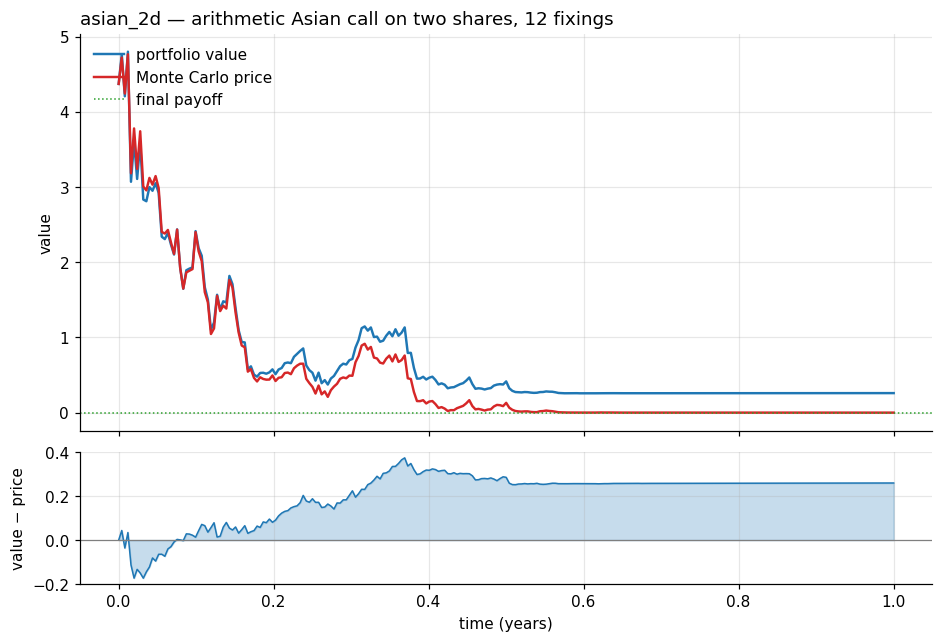

gap: max +0.374   min -0.173   final P&L +0.260
deltas at t = 0       [0.332 0.219]
deltas at t = 0.5     [0.026 0.017]
deltas at t = T       [0. 0.]


In [9]:
gap = plot_tracking("asian_2d", "asian_2d — arithmetic Asian call on two shares, 12 fixings", "asian_2d.png")
d = deltas("asian_2d")
print(f"gap: max {gap.max():+.3f}   min {gap.min():+.3f}   final P&L {hedge('asian_2d')['finalPnL']:+.3f}")
print("deltas at t = 0      ", np.round(d.iloc[0].values, 3))
print("deltas at t = 0.5    ", np.round(d.iloc[len(d) // 2].values, 3))
print("deltas at t = T      ", np.round(d.iloc[-1].values, 3))

The basket drifts from 100 to 76 and every fixing after the first lands below the strike. Each one
that gets locked in lowers the best the average can still reach; by day 134 the price is below 0.01
and the deltas, already down to `[0.026, 0.017]` at mid-year, are zero. From there the portfolio is
cash only and the gap freezes at its final value, +0.26.

The step at each fixing is visible in the top panel: between fixings the price moves with the
spot, at a fixing one more term of the average becomes known and the option's variance drops.
The early gap swings to −0.17 and +0.37 while the option is still alive and gamma is highest, then
nothing more happens — the same self-financing recursion runs on for 118 more days with constant
deltas and only the risk-free interest changes the value.

## A payoff that is almost delta-neutral: the performance option

`perf_4d` pays `1 + Σᵢ (basket_{tᵢ} / basket_{tᵢ₋₁} − 1)⁺` over 12 periods on four shares. It only
looks at *returns*, so scaling every price by the same factor leaves it unchanged: the payoff is
homogeneous of degree 0 in the price vector and `Σ_d S_d·δ_d = 0`. On day 0 the four shares are
exchangeable on top of that, so every individual delta has to vanish. From day 1 the previous
fixing is locked in and today's spot enters the current period's return, so a small delta appears:
of order `w_d / basket ≈ 0.25 / 100`.

day 0:  delta [ 3.2e-07  3.7e-07 -1.4e-06  7.0e-07]   std [1.6e-06 1.6e-06 1.6e-06 1.6e-06]
after:  max |delta| 2.81e-03   (std ≈ 5e-06, so genuinely non-zero)
        shares held at most 1.084 against a price of 1.245


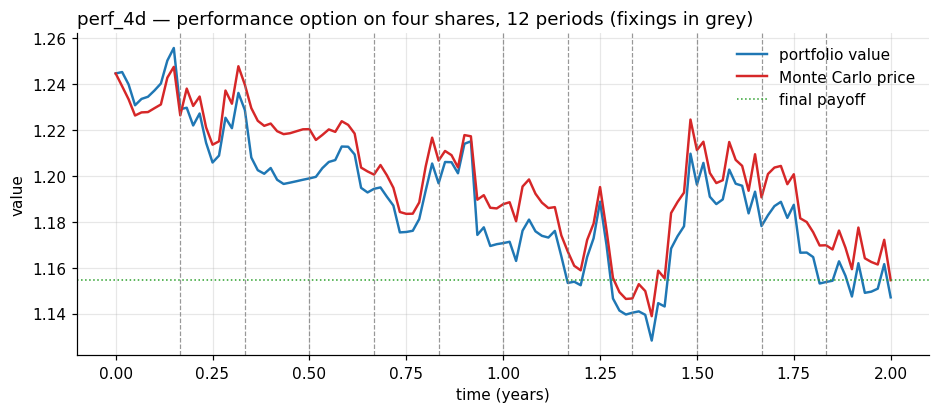

final P&L -0.0075   (-0.6% of the premium)


In [10]:
d = deltas("perf_4d"); df = journal("perf_4d")
sd = pd.DataFrame(df["deltasStdDev"].tolist(), index=df.index)
print("day 0:  delta", np.array2string(d.iloc[0].values, precision=1), "  std", np.array2string(sd.iloc[0].values, precision=1))
print(f"after:  max |delta| {d.iloc[1:].abs().values.max():.2e}   (std ≈ {sd.iloc[1:].values.mean():.0e}, so genuinely non-zero)")
print(f"        shares held at most {(d * market('perf_4d')).sum(axis=1).max():.3f} against a price of {df.price.iloc[0]:.3f}")

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(df.index, df.value, color=BLUE, lw=1.6, label="portfolio value")
ax.plot(df.index, df.price, color=RED, lw=1.6, label="Monte Carlo price")
ax.axhline(hedge("perf_4d")["finalPayoff"], color=GREEN, lw=1.0, ls=":", label="final payoff")
for i in range(1, 12):
    ax.axvline(i * 2.0 / 12, color=GREY, lw=0.8, alpha=0.8, ls="--")
ax.set_title("perf_4d — performance option on four shares, 12 periods (fixings in grey)", loc="left", fontsize=12)
ax.set_xlabel("time (years)"); ax.set_ylabel("value"); ax.legend(loc="upper right")
fig.savefig(PLOTS / "perf_4d.png", bbox_inches="tight")
plt.show()
print(f"final P&L {hedge('perf_4d')['finalPnL']:+.4f}   ({hedge('perf_4d')['finalPnL'] / df.price.iloc[0]:+.1%} of the premium)")

On day 0 the four deltas are of order 1e-6 with a standard deviation of 1.6e-6 — zero to Monte Carlo
precision. From day 1 they are 1e-3 to 3e-3 with a standard deviation of 5e-6: several hundred
standard deviations from zero, so a real sensitivity, not noise. In money terms the hedge holds up
to 1.08 in shares against a premium of 1.24, mostly at the end of each period, and the final P&L is
−0.0075 (−0.6 % of the premium).

The sawtooth in the price is the payoff's structure: within a period the current return is
uncertain and the price moves with the basket; at each fixing (grey lines) that return is locked in
and the price steps to a new base.

## The cash recursion, replayed independently

The C++ portfolio is `V₀ = p₀ − δ₀·S₀`, then `Vᵢ = Vᵢ₋₁·e^{rT/H} − (δᵢ − δᵢ₋₁)·Sᵢ`, with
`valueᵢ = Vᵢ + δᵢ·Sᵢ`. Replaying it in numpy from the deltas the pricer wrote out, on the market file it
read, has to give back the `value` column bit for bit.

In [11]:
def replay(name):
    p, h = params(name), hedge(name)
    S, d = market(name), deltas(name).values
    r, T, H = p["model"]["rate"], p["option"]["maturity"], p["hedging"]["rebalancingDates"]
    growth = math.exp(r * T / H)
    cash = h["portfolio"][0]["price"] - d[0] @ S[0]
    values = [cash + d[0] @ S[0]]
    for i in range(1, H + 1):
        cash = cash * growth - (d[i] - d[i - 1]) @ S[i]
        values.append(cash + d[i] @ S[i])
    return np.array(values)

for name in names:
    gap = np.abs(replay(name) - journal(name).value.values).max()
    print(f"{name:11s} max |replay − value| = {gap:.1e}")

call_1d     max |replay − value| = 0.0e+00
basket_3d   max |replay − value| = 1.8e-13
asian_2d    max |replay − value| = 1.6e-14
perf_4d     max |replay − value| = 1.8e-15
basket_10d  max |replay − value| = 2.1e-13


## Convergence in the number of paths

Pricing `call_1d` with 500 to 200 000 paths. The reported standard deviation is
`e^{-rT}·√(Var(payoff)/M)`, so it has to fall like `M^{-1/2}`, and the closed-form price has to sit
inside the error bars.

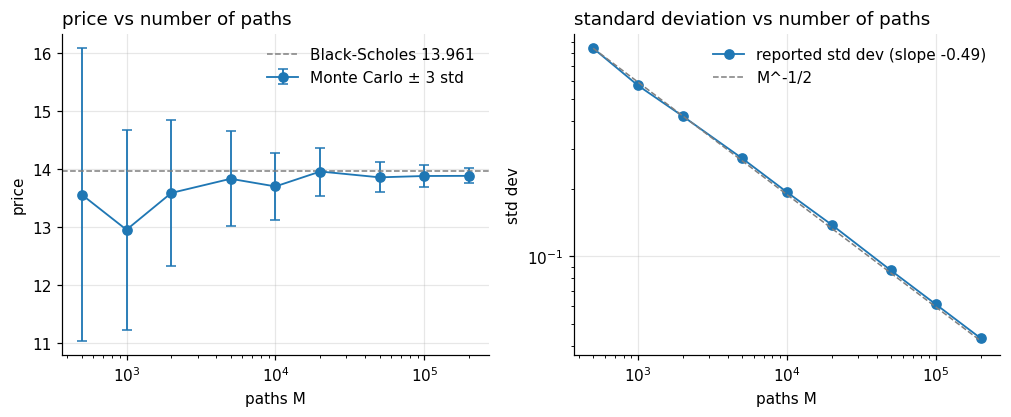

log-log slope of std dev: -0.492   z-scores: [-0.47 -1.75 -0.88 -0.46 -1.34 -0.   -1.17 -1.27 -1.74]
seconds per run: [0.003, 0.002, 0.002, 0.002, 0.003, 0.004, 0.008, 0.012, 0.024]


In [12]:
sw = pd.read_csv(RESULTS / "sweep_samples.csv")
bs_price, bs_delta = bs_call(100.0, K, T, r, sigma)
slope = np.polyfit(np.log(sw.samples), np.log(sw.priceStdDev), 1)[0]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax.errorbar(sw.samples, sw.price, yerr=3 * sw.priceStdDev, fmt="o-", color=BLUE, lw=1.2, capsize=3, label="Monte Carlo ± 3 std")
ax.axhline(bs_price, color=GREY, ls="--", lw=1.0, label=f"Black-Scholes {bs_price:.3f}")
ax.set_xscale("log"); ax.set_xlabel("paths M"); ax.set_ylabel("price"); ax.legend(loc="upper right")
ax.set_title("price vs number of paths", loc="left", fontsize=12)
ax2.loglog(sw.samples, sw.priceStdDev, "o-", color=BLUE, lw=1.2, label=f"reported std dev (slope {slope:.2f})")
ax2.loglog(sw.samples, sw.priceStdDev.iloc[0] * np.sqrt(sw.samples.iloc[0] / sw.samples), color=GREY, ls="--", lw=1.0, label="M^-1/2")
ax2.set_xlabel("paths M"); ax2.set_ylabel("std dev"); ax2.legend(loc="upper right")
ax2.set_title("standard deviation vs number of paths", loc="left", fontsize=12)
fig.savefig(PLOTS / "convergence.png", bbox_inches="tight")
plt.show()

z = (sw.price - bs_price) / sw.priceStdDev
print(f"log-log slope of std dev: {slope:.3f}   z-scores: {np.round(z.values, 2)}")
print(f"seconds per run: {sw.seconds.tolist()}")

The log-log slope of the reported standard deviation is −0.49, and Black-Scholes is inside the
3-standard-deviation bar at every one of the nine sizes, from 500 paths (±2.5) to 200 000 (±0.13).
All nine z-scores are negative because the runs share a seed: the first 500 paths of every
estimate are the same 500 paths, so these are not nine independent draws but nine views of one
converging sequence. The whole sweep takes 60 ms.

## The finite-difference step

Deltas are central differences `[φ(S(1+h)) − φ(S(1−h))] / (2·S·h)` on the same random paths.
Common random numbers keep the Monte Carlo noise flat in `h`; what does move is the `O(h²)`
truncation bias, visible here because 200 000 paths make the noise small.

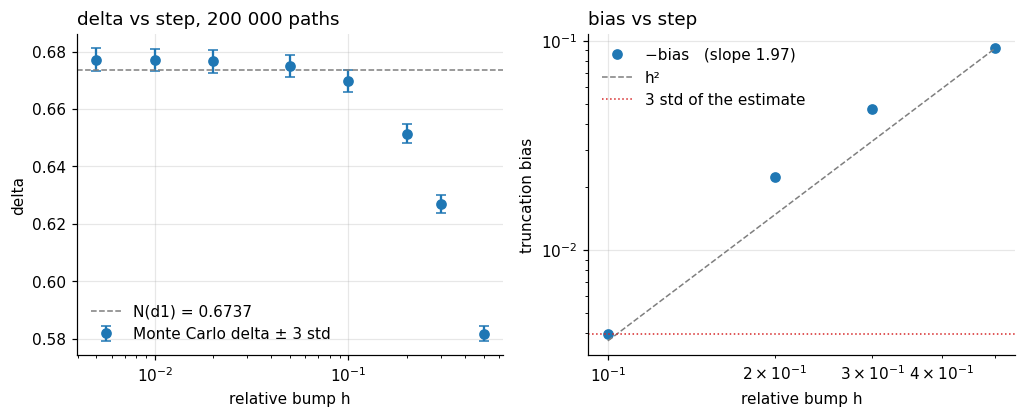

 fdStep   delta  deltaStdDev     bias          z
  0.005 0.67716      0.00132  0.00346    2.61351
  0.010 0.67700      0.00132  0.00329    2.49889
  0.020 0.67662      0.00131  0.00291    2.22093
  0.050 0.67496      0.00128  0.00125    0.97553
  0.100 0.66975      0.00124 -0.00396   -3.18676
  0.200 0.65142      0.00115 -0.02228  -19.37237
  0.300 0.62675      0.00105 -0.04696  -44.80635
  0.500 0.58174      0.00084 -0.09197 -110.05118


In [13]:
fd = pd.read_csv(RESULTS / "sweep_fdstep.csv").sort_values("fdStep")
fd["bias"] = fd.delta - bs_delta
fd["z"] = fd.bias / fd.deltaStdDev
big = fd[fd.fdStep >= 0.1]
slope_h = np.polyfit(np.log(big.fdStep), np.log(-big.bias), 1)[0]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax.errorbar(fd.fdStep, fd.delta, yerr=3 * fd.deltaStdDev, fmt="o", color=BLUE, capsize=3, label="Monte Carlo delta ± 3 std")
ax.axhline(bs_delta, color=GREY, ls="--", lw=1.0, label=f"N(d1) = {bs_delta:.4f}")
ax.set_xscale("log"); ax.set_xlabel("relative bump h"); ax.set_ylabel("delta"); ax.legend(loc="lower left")
ax.set_title("delta vs step, 200 000 paths", loc="left", fontsize=12)
ax2.loglog(big.fdStep, -big.bias, "o", color=BLUE, label=f"−bias   (slope {slope_h:.2f})")
ax2.loglog(big.fdStep, -big.bias.iloc[-1] * (big.fdStep / big.fdStep.iloc[-1])**2, color=GREY, ls="--", lw=1.0, label="h²")
ax2.axhline(3 * fd.deltaStdDev.max(), color=RED, ls=":", lw=1.0, label="3 std of the estimate")
ax2.set_xlabel("relative bump h"); ax2.set_ylabel("truncation bias"); ax2.legend(loc="upper left")
ax2.set_title("bias vs step", loc="left", fontsize=12)
fig.savefig(PLOTS / "fd_step.png", bbox_inches="tight")
plt.show()
print(fd.round(5).to_string(index=False))

Two things are visible. The standard deviation of the delta estimate does not grow as `h` shrinks —
it is 0.0013 at `h = 0.5 %` and 0.0008 at `h = 50 %` — because up and down paths use the same
random numbers and the payoff difference stays smooth in `h`. And the truncation bias grows like
`h²` (log-log slope 2.0 on the right): −0.004 at 10 % (3 standard deviations), −0.022 at 20 % and
−0.092 at 50 %. A 10 % bump on a call struck 5 % below the spot straddles the kink, and the central
difference then averages the delta over that window instead of evaluating it at the spot. Below
5 % the four estimates agree with each other to 3·10⁻⁴ — the truncation bias is gone — and sit
0.003 (2.5 standard deviations) above N(d1), which is the Monte Carlo error of this particular
seed, shared by all of them. The scenarios above use `h = 1 %`.

## Cost

One Monte Carlo delta vector reuses each simulated path for every one of the D shares, so a full
price-and-delta evaluation costs `M` path simulations plus `2·D·M` payoff evaluations, whatever `D`.

In [14]:
timings.assign(dates=[params(n)["hedging"]["rebalancingDates"] + 1 for n in timings.index]) \
       .assign(ms_per_date=lambda t: 1000 * t.hedge_seconds / t.dates) \
       .round(2)

,price_seconds,hedge_seconds,dates,ms_per_date
scenario,,,,
asian_2d,0.08,11.09,253,43.83
basket_10d,0.05,12.62,251,50.28
basket_3d,0.02,3.55,253,14.03
call_1d,0.01,1.47,253,5.81
perf_4d,0.17,11.88,121,98.18


One share costs 6 ms per date, three cost 14 ms, ten cost 50 ms: roughly linear in `D`, through the
`2·D` payoff evaluations per path, since the path simulation itself is shared across the shares.
`perf_4d` is the most expensive per date because its payoff walks all 13 rows of the path for each of
the `2·D + 1` evaluations. A full daily hedge over a year, re-pricing with 50 000 paths at each of
the 253 dates, runs in 1.5 to 13 seconds.